# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

In [2]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
from cycler import cycler
%matplotlib inline
from matplotlib.colors import Normalize
import matplotlib.image as mpimg
import h5py
import cmasher as cmr
import pandas as pd

from matplotlib import cm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, SymmetricalLogLocator
import matplotlib.patches as mpatches
from scipy.interpolate import splprep, splev
from matplotlib.patches import PathPatch
import matplotlib.lines as mlines

import sys
sys.path.append("../utils")
from utils import *
import cmcrameri.cm as cmc
from matplotlib.path import Path

# Physical constants
h = 6.626E-34  # Planck constant (J·s)
e = 1.6002E-19  # Elementary charge (C)
phi0 = h / e    # Flux quantum (Wb)
Rq = h/e**2
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [3]:
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})


In [4]:
dtg=rmg19['default']['dtg']
print(dtg)

17.406


# Load Dan's files

In [5]:
def load_LL_simulation_data(filepath, group="LL_simulation_data"):
    with h5py.File(filepath, "r") as f:
        return deserialize_LL_simulation_data(f[group])

def deserialize_LL_simulation_data(g):
    assert g.attrs["type"] == b'LL_simulation_data'

    sg = g["rhparams"]
    rhparams = {
        "n":      int(sg["n"][()]),
        "t0":     float(sg["t0"][()]),
        "t1":     float(sg["t1"][()]),
        "t2":     float(sg["t2"][()]),
        "t3":     float(sg["t3"][()]),
        "t4":     float(sg["t4"][()]),
        "delta":  float(sg["delta"][()]),
        "Deltas": sg["Deltas"][()],
    }

    # fluxes_pq: Julia writes (2, Nflux), h5py reads (Nflux, 2) due to C/Fortran order swap
    fluxes_pq = g["fluxes_pq"][()]
    fluxes = [(int(row[0]), int(row[1])) for row in fluxes_pq]

    ns_lin = np.linspace(
        float(g["ns_lin_start"][()]),
        float(g["ns_lin_stop"][()]),
        int(g["ns_lin_length"][()]),
    )

    return {
        "rhparams":             rhparams,
        "uD_meV":               float(g["uD_meV"][()]),
        "valley":               int(g["valley"][()]),
        "Nll":                  int(g["Nll"][()]),
        "T0_meV":               float(g["T0_meV"][()]),
        "Nenergies":            int(g["Nenergies"][()]),
        "fluxes":               fluxes,   # list of (p, q) int tuples
        "Es_all":               g["Es_all"][()],
        "ns_lines":             g["ns_lines"][()],
        "rhos_single_particle": g["rhos_single_particle"][()],
        "ns_lin":               ns_lin,
    }

# Helper functions for FFT analysis

In [6]:
class Lf_analysis:
    def __init__(self, file, contact, is_exp_data=True):
        if is_exp_data:
            data = sl.pload(file_path, file)
            self.B_raw = data['ys'][0]
            self.Rxx_raw = data[f'sr830_{contact}_X']/data['sr830_4_X']
            Vtgs = data['xs'][0]
            Vbgs = data['xs'][1]
            self.density, _ = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
        else:
            self.data = load_LL_simulation_data(file)
            self.density = self.data["ns_lin"][1:] # remove zero density
            fluxes = self.data["fluxes"]
            self.B_raw = np.array([78912.31601883237*phi[0]/phi[1] for phi in fluxes])
            self.Rxx_raw = self.data["rhos_single_particle"][:,1:] # remove zero density
            

    # @lru_cache(maxsize=1)
    def get_bg_subtracted_data(self, bg_method, bg_method_params, blims, return_bg=False):
        """ 
            Do background subtraction on data 
            bg_method is function that takes in a row in B, Rxx and subtracts it
            blims is (low, high) bounds for B
        """
        # Limit our B
        blo, bhi = blims
        bmask = (blo < self.B_raw) & (self.B_raw < bhi)
        bflat = np.abs(np.diff(self.B_raw[bmask])) > 0 # get rid of parts where b is flat
        bmask[bmask] = bmask[bmask] & np.append(bflat, 1) & np.insert(bflat, 0, 1)
        B = self.B_raw[bmask] 
        Rxx_raw = self.Rxx_raw[bmask]    
        # Do a background subtraction on each line
        Rxx_detrended = np.zeros_like(Rxx_raw)
        for i, cut in enumerate(Rxx_raw.T):
            Rxx_detrended[:,i], _ = bg_method(B, cut, **bg_method_params)
        if return_bg:
            return B, Rxx_detrended, Rxx_raw - Rxx_detrended
        return B, Rxx_detrended


    # @lru_cache(maxsize=10)
    def get_fft(self, bg_method, bg_method_params, padding, blims, num_pts_max=5000):
        B, Rxx_detrended = self.get_bg_subtracted_data(bg_method, bg_method_params, blims)
        invB_range = np.max(1/B) - np.min(1/B)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/B)))))
        if num_invB_pts > num_pts_max:
            num_invB_pts = num_pts_max
        ffts = np.zeros((int(num_invB_pts*(2*padding+1)/2), len(self.density)), dtype=complex)
        freqs = np.zeros((int(num_invB_pts*(2*padding+1)/2), len(self.density)))
        for i, cut in enumerate(Rxx_detrended.T):
            interp_invB, interp_cut = interp_rxx(B, cut, nx=num_invB_pts, type='cubic')
            fft, freq = make_vec_fft(interp_invB, interp_cut, n=self.density[i], padding=padding, return_complex=True)
            ffts[:,i] = fft[:len(freq)//2]
            freqs[:,i] = freq[:len(freq)//2]

        return ffts, freqs
    
    def get_fft_line(self, target_density, bg_method, bg_method_params, padding, blims):
        # As get fft, but only get one line in density
        density_idx = np.argmin(np.abs(self.density-target_density))
        blo, bhi = blims
        bmask = (blo < self.B_raw) & (self.B_raw < bhi)
        bflat = np.abs(np.diff(self.B_raw[bmask])) > 0 # get rid of parts where b is flat
        bmask[bmask] = bmask[bmask] & np.append(bflat, 1) & np.insert(bflat, 0, 1)
        B = self.B_raw[bmask] 
        Rxx_raw = self.Rxx_raw[bmask, density_idx]        
        Rxx_detrended, _ = bg_method(B, Rxx_raw, **bg_method_params)
        invB_range = np.max(1/B) - np.min(1/B)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/B)))))
        interp_invB, interp_cut = interp_rxx(B, Rxx_detrended, nx=num_invB_pts, type='cubic')
        psd, freq = make_vec_fft(interp_invB, interp_cut, n=self.density[density_idx], padding=padding, normalize=False)
        psd = psd[:len(freq)//2]
        freq = freq[:len(freq)//2]
        return psd, freq

    @staticmethod
    def get_fft_peak(freq, fft, target_peak_val):
        # Given a cut in freq and peak, find peaks most closely matching target_peak_vals
        peaks, _ = find_peaks(np.abs(fft)**2, prominence=0.1)
        if len(peaks) < 1:
            return np.nan, np.nan
    
        peak_v = peaks[np.argmin(np.abs(freq[peaks] - target_peak_val))]
        
        return fft[peak_v], freq[peak_v]

    def plot_blim_effect(self, fig, ax, norm, bg_method, bg_method_params, padding, bhi_max, blo_min, target_density, target_freq, n_B_lims=60):
        min_window_len = 0.2

        b_mins = np.linspace(blo_min, 2.0, num=n_B_lims)
        b_maxes = np.linspace(blo_min+min_window_len, bhi_max, num=n_B_lims)

        fft_coefs_out = np.zeros((n_B_lims, n_B_lims)) * np.nan
        freqs_out = np.zeros((n_B_lims, n_B_lims)) * np.nan

        density_val = self.density[np.argmin(np.abs(self.density-target_density))]        
        for j, blo in enumerate(b_mins):
            for k, bhi in enumerate(b_maxes):
                if bhi - blo < min_window_len:
                    # Skip windows that are too small
                    fft_coefs_out[j,k], freqs_out[j,k] = np.nan, np.nan
                    continue
                
                psds, freqs = self.get_fft_line(target_density, bg_method, bg_method_params, padding, blims=(blo, bhi))
                fft, freq = self.get_fft_peak(freqs, psds, target_freq)
                fft_coefs_out[j,k], freqs_out[j,k] = np.abs(fft)**2, freq
        
        ax.set_facecolor('k')
        plot = ax.pcolormesh(
            b_mins, b_maxes, freqs_out.T*density_val,  rasterized=True,
            norm=norm, cmap='RdBu_r'
        )
        
        ax.set_xlabel("Low field cutoff (T)")
        ax.set_ylabel("High field cutoff (T)")
        return plot
    

    def plot_bw_filter_effect(self, fig, ax, norm, padding, target_density, target_freq, n_filters=60):
        min_window_len = 0.2

        filters = np.linspace(0, 50.0, num=n_filters)
        orders = np.arange(7, dtype=int)

        fft_coefs_out = np.zeros((n_filters, 7)) * np.nan
        freqs_out = np.zeros((n_filters, 7)) * np.nan

        density_val = self.density[np.argmin(np.abs(self.density-target_density))]        
        for j, filter_cutoff in enumerate(filters):
            for k, order in enumerate(orders):
              
                psds, freqs = self.get_fft_line(target_density, detrend_butterworth, {'cutoff': filter_cutoff, 'order': order}, padding, blims=(0.62, 4.98))
                fft_coefs_out[j,k], freqs_out[j,k] = self.get_fft_peak(freqs, psds, target_freq)
        
        ax.set_facecolor('k')
        plot = ax.pcolormesh(
            filters, orders, freqs_out.T*density_val,  rasterized=True,
            norm=norm, cmap='RdBu_r'
        )
        
        ax.set_xlabel(r"Filter Cutoff ($T^{-1}$)")
        ax.set_ylabel("Filter Order")
        return plot


    def plot_fft(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        psds = np.abs(ffts)**2
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))

        plot = ax.pcolormesh(density_repeated, freqs, psds, norm=norm, cmap='viridis', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(nh/e)$')
        ax.set_ylim(0, 3)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq = psds[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f)

        return plot
    

    def plot_fft_invcm(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))
        # Grey out freq cutoff
        psds = np.abs(ffts)**2
        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, psds, norm=norm, cmap='viridis', rasterized=True, lw=0)
        
        
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 2)


        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq =  psds[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f*self.density[density_idx])
         
        return plot

    def plot_fft_invcm_phase(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        angles = np.angle(ffts, deg=True) %180
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.Normalize(vmin=0, vmax=180)

        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, angles, norm=norm, cmap='twilight', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 2)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq =  angles[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f*self.density[density_idx])
         

        return plot



    def plot_fft_grad(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49)):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        psds = np.abs(ffts)**2
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        # def fft_deriv(linecut):
        #     # derivative down to a constant
        #     N = 6*len(linecut)
        #     fft = scipy.fft.rfft(linecut, n=N)
        #     freq = scipy.fft.rfftfreq(N)
        #     return scipy.fft.irfft(1j*freq*fft)[:len(linecut)]
            
        # deriv = np.apply_along_axis(fft_deriv, 0, psds)
        deriv = np.gradient(psds, axis=0)
        # deriv /= np.mean(np.abs(deriv), axis=0)
        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, 1/np.abs(deriv), norm=norm, cmap='viridis', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 3)
        return plot, deriv

    def get_peak_locs(self, fig, ax, bg_method, bg_method_params, padding, blims=(0.51, 2.49), density_lims=(0.35, 0.65)):
        nlo, nhi = density_lims
        density_mask = (nlo < self.density) & (self.density < nhi)
        target_peaks = np.array([1.155, 0.925])/self.density[density_mask,np.newaxis]

        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        peaks_out = np.zeros_like(target_peaks)
        peaks_coefs = np.zeros_like(target_peaks, dtype=complex)
        for i, (density, peaks, fft, freq) in enumerate(zip(self.density[density_mask], target_peaks, ffts.T, freqs.T)):
            for j, peak in enumerate(peaks):
                ft, fr = self.get_fft_peak(freq, fft, peak)
                peaks_out[i,j] = fr*density # Output freq in 10^12 cm-2
                peaks_coefs[i,j] = ft
        ax.plot(self.density[density_mask], peaks_out[:,0], '.')
        ax.plot(self.density[density_mask], peaks_out[:,1], '.')
        return plot, peaks_out, peaks_coefs

In [7]:
def plot_fft_linecut(fig, ax, target_density, filter_method="poly", analyzer=None, norm_skip_fraction=0.4,\
                    padding=8, filter_lims=(0.9,5), linecut_color="b"):
    filter_lowB, filter_highB = filter_lims
    
    if filter_method == "poly":
        fft, freq = analyzer.get_fft(detrend_poly, {'degree': 1}, padding, (filter_lowB, filter_highB))
    elif filter_method == "spline":
        fft, freq = analyzer.get_fft(detrend_spline, {'n_knots': 6}, padding, (filter_lowB, filter_highB))
    elif filter_method == "butter":
        fft, freq = analyzer.get_fft(detrend_butterworth, {'cutoff': None, 'order' : 4}, padding, (filter_lowB, filter_highB))
    else:
        print("Unknown method")
        return
        
    
    density_idx = np.argmin(np.abs(analyzer.density - target_density))
    density_res = analyzer.density[density_idx]
    fft_norm = np.max(np.abs(fft[:, density_idx])[int(1.0*norm_skip_fraction*fft.shape[0]):])
    fft_abs = np.abs(fft[:, density_idx])/fft_norm
    psd = fft_abs**2
    
    im = ax.plot(freq[:, density_idx], psd, color=linecut_color)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel(r'$n_{\mathrm{SdH}}/n$')
    ax.set_ylabel('|FFT|$^2$ (a.u.)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(8))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

# a - Landau Fan at D = 1 V/nm

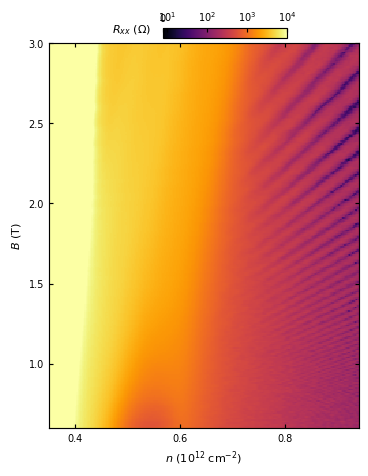

In [8]:
def plot_landau_fan(fig, ax, norm, cmap="viridis"):
    file = 1840
    contact = 3 # choose which contact pair to plot = 1,2,3  
    data = sl.pload(file_path, file)
    ys = data['ys'][0]
    zs = data[f'sr830_{contact}_X']/data['sr830_4_X']
    zs = zs
    
    Vtgs = data['xs'][0]
    Vbgs = data['xs'][1]
    xs, _ = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlim(0.35, 0.94)
    #ax.set_ylim(0.8, 5)
    ax.set_ylim(0.6, 3)
    #ax.plot([0.50, 0.50], [0.8,1.1], color="white", ls="--")
    #ax.plot([0.60, 0.60], [0.8,1.1], color="white", ls="--")
    #ax.text(0.52, 0.9, "CSC", color="white",fontweight="bold")
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot

fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=1E4)
plot = plot_landau_fan(fig, ax, norm, "inferno")

cax = fig.add_axes([0.41, 0.89, 0.31, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=10), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-17, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

#ax.xaxis.set_major_locator(plt.MaxNLocator(6))
#ax.set_xlim(0.65, 0.84)

# b - Detrended Landau fan

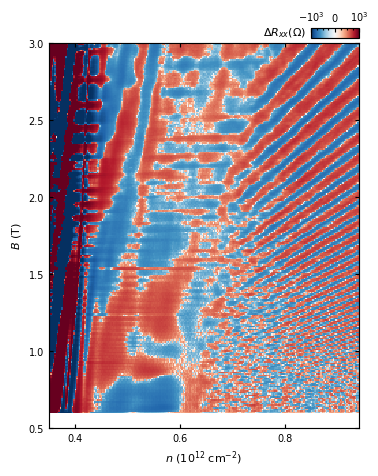

In [9]:
def plot_landau_fan_detrend(fig, ax, norm, cmap="viridis"):
    analyzer = Lf_analysis(1840, contact=2)
    n_vec = analyzer.density
    B_vec, Rxx_detrended = analyzer.get_bg_subtracted_data(bg_method=detrend_butterworth, \
                                              bg_method_params={'cutoff': None, 'order' : 4}, 
                                              blims=(0.2, 5), return_bg=False)
    
    
    plot = ax.pcolormesh(n_vec, B_vec, Rxx_detrended, norm=norm, cmap=cmap, rasterized=True)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlim(0.35, 0.94)
    #ax.axvline(0.5, ls="--", color="white")
    #ax.axvline(0.62, ls="--", color="white")
    ax.set_ylim(0.5, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot

fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot = plot_landau_fan_detrend(fig, ax, norm, "RdBu_r")

pos = ax.get_position()
cb_width = 0.12
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], \
                  orientation='horizontal')
cb.ax.annotate('$\Delta R_{xx} (\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top') 
cb.set_ticklabels(['$-10^3$', '$0$', '$10^3$'])


# c - theory LLs

In [10]:
def plot_theory_LL(fig, ax, file, norm, cmap):
    analyzer = Lf_analysis(file, contact=0, is_exp_data=False)
   
    n_vec = analyzer.density
    print(analyzer.B_raw)
    plot = ax.pcolormesh(analyzer.density, analyzer.B_raw, analyzer.Rxx_raw, norm=norm, cmap=cmap, \
                         rasterized=True, lw=0)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.set_xlim(0.35, 0.94)
    ax.set_ylim(0.7, 3)
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')

    return plot

[0.00986404 0.01109704 0.01233005 ... 3.78532516 3.78655816 3.78779117]


Text(0.97, 0.97, 'Theory')

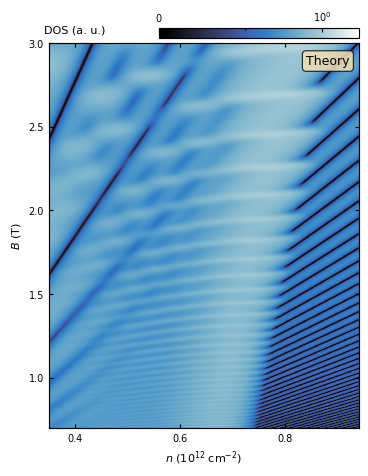

In [11]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()

uD, val = 43, 1
file = "../data/fig3/data_LL_uD_{:d}.0_Nll_150_val_{:d}_Bmin_0.01T_Bmax_3.79T_T_0.02500.h5".format(uD, val)
norm = colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=3)
plot = plot_theory_LL(fig, ax, file, norm, cmr.arctic)

pos = ax.get_position()
cb_width = 0.5
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=[0,1], \
                  orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'DOS (a. u.)', labelpad=-17, x=-0.42)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')   

from matplotlib.patches import FancyBboxPatch

# After your imshow/colorbar setup, add to your axes:
ax.text(0.97, 0.97, 'Theory', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=0.85))

# d - FFT linecuts

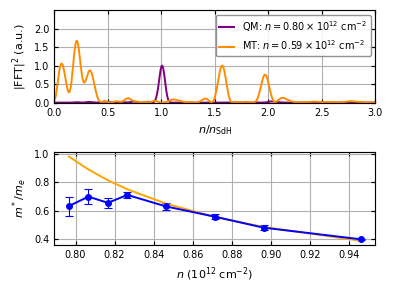

In [156]:
fig, axarr = plt.subplots(2,1, figsize=(4,3))
analyzer = Lf_analysis(1840, contact=2)
target_densities = [0.8, 0.59]
label_vec = ["QM", "MT"]
padding = 4
filter_lims = (1, 4)
linecut_colors = ["#785EF0", "#FFB000"]
linecut_colors = ["purple", "#FF8C00"]
for density_ind, target_density in enumerate(target_densities):
    ax = axarr[0]
    plot_fft_linecut(fig, ax, target_density=target_density, filter_method="butter", \
                     analyzer=analyzer, norm_skip_fraction=0.04, padding=padding, filter_lims = filter_lims,\
                    linecut_color = linecut_colors[density_ind])
    ax.set_xlim(0, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(7))
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax.grid(True)

label_str = "\n".join(
    f"{label}: $n = {d:.2f}\\times 10^{{12}}$ cm$^{{-2}}$"
    for label, d in zip(label_vec, target_densities)
)
legend_handles = [
    mlines.Line2D([], [], color=linecut_colors[i], linewidth=1.5,
                  label=f"{label}: $n = {d:.2f}\\times 10^{{12}}$ cm$^{{-2}}$")
    for i, (label, d) in enumerate(zip(label_vec, target_densities))
]
axarr[0].legend(handles=legend_handles, loc='upper right', fontsize=7,
                framealpha=0.85, edgecolor='gray', handlelength=1.5)

axarr[0].set_ylim(0,2.5)
axarr[0].yaxis.set_ticks([0,0.5, 1,1.5,2])

def load_mstar(path):
    """Return (n, mstar, error) arrays from a figS_mstar CSV."""
    df = pd.read_csv(path)
    return df["n"].to_numpy(), df["mstar"].to_numpy(), df["mstar_stdev"].to_numpy()

# usage
n_data, mstar_data, err_data = load_mstar("../data/fig3/figS_mstar_qm_B3-B4_big.csv")

num_pts=8
axarr[1].errorbar(n_data[:num_pts], mstar_data[:num_pts], yerr=error_data[:num_pts],
                  marker="o", color="blue", linestyle="-", markersize=4,
                  capsize=3, capthick=0.8, elinewidth=0.8, ecolor="blue")
axarr[1].plot(n_data[:num_pts], 0.095/(n_data[:num_pts] - 0.7), color="orange")
axarr[1].set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
axarr[1].set_ylabel(r"$m^*/m_e$")
axarr[1].yaxis.set_major_locator(plt.MaxNLocator(4))
axarr[1].grid(True)
plt.tight_layout()

# e - FFT

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/4038291762.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax.pcolormesh(xs_repeated, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, rasterized=True, lw=0)


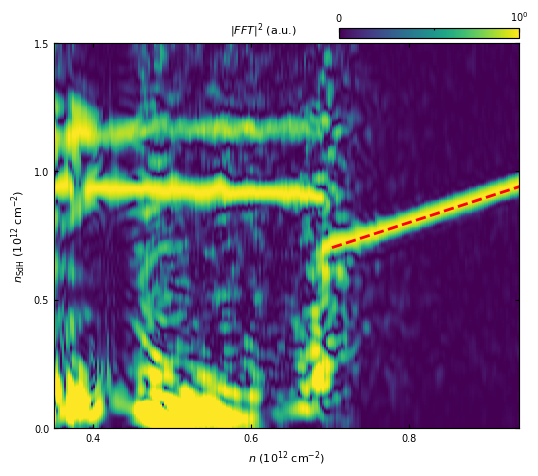

In [177]:
def plot_fft(fig, ax, norm, cmap="viridis"):
    analyzer = Lf_analysis(1840, contact=3)
    n_vec = analyzer.density
    ffts, freqs = analyzer.get_fft(bg_method=detrend_butterworth, \
                                              bg_method_params={'cutoff': None, 'order' : 2}, 
                                              padding=4, blims=(1, 4))

    xs_repeated = np.tile(n_vec, (freqs.shape[0], 1))
    unnorm_freqs = np.array([f*n_vec for f in freqs])
    psds = np.abs(ffts)**2
    if norm is None:
        # Default to lognorm
        norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))

    norm_skip_fraction = 0.03 # how much of the low freq to skip to find max
    norm_psds = np.array([p/(p[int(norm_skip_fraction*psds.T[0].shape[0]):].max()) for p in psds.T])
    #norm_psds = psds
    plot = ax.pcolormesh(xs_repeated, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, rasterized=True, lw=0)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0.35, 0.94)
    #ax.axhline(1, color='r', linestyle='--')
    #ax.axvline(0.5, ls="--", color="white")
    #ax.axvline(0.62, ls="--", color="white")
    xs_qm = n_vec[:np.argmin(np.abs(n_vec - 0.7))] # density axis only in qm
    ax.plot(xs_qm, xs_qm, ls="--", color="r", lw=2)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    return plot

fig = plt.figure(figsize=(6,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=1)
#norm = colors.Normalize(vmin=0, vmax=1)
plot = plot_fft(fig, ax, norm=norm, cmap="viridis")

pos = ax.get_position()
cb_width = 0.3
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=[0,1], \
                  orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$|FFT|^2$ (a.u.)', labelpad=-17, x=-0.42)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

#ax.set_xlim(0.65, 0.82)

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/1683501260.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax.pcolormesh(xs_repeated, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, rasterized=True, lw=0)
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/1683501260.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


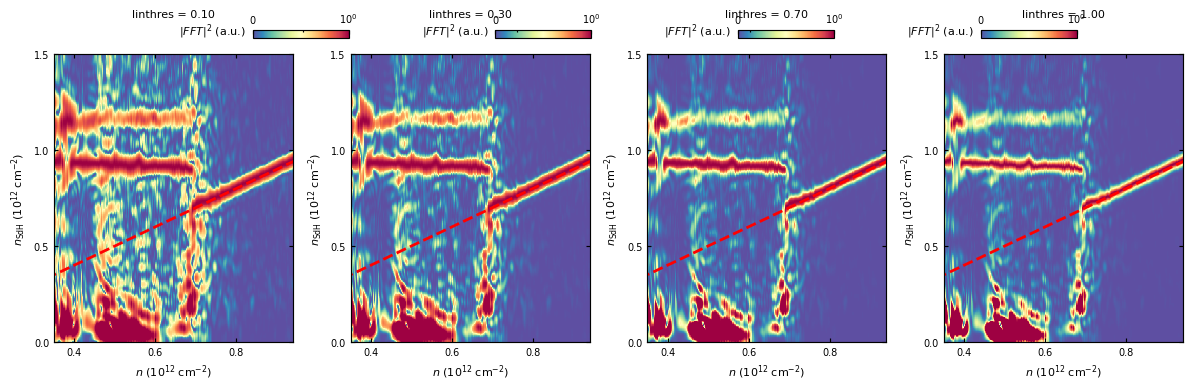

In [174]:
def plot_fft(fig, ax, norm, cmap="viridis"):
    analyzer = Lf_analysis(1840, contact=3)
    n_vec = analyzer.density
    ffts, freqs = analyzer.get_fft(bg_method=detrend_butterworth, \
                                              bg_method_params={'cutoff': None, 'order' : 2}, 
                                              padding=4, blims=(1, 4))

    xs_repeated = np.tile(n_vec, (freqs.shape[0], 1))
    unnorm_freqs = np.array([f*n_vec for f in freqs])
    psds = np.abs(ffts)**2
    if norm is None:
        # Default to lognorm
        norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))

    norm_skip_fraction = 0.03 # how much of the low freq to skip to find max
    norm_psds = np.array([p/(p[int(norm_skip_fraction*psds.T[0].shape[0]):].max()) for p in psds.T])
    #norm_psds = psds
    plot = ax.pcolormesh(xs_repeated, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, rasterized=True, lw=0)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0.35, 0.94)
    #ax.axhline(1, color='r', linestyle='--')
    #ax.axvline(0.5, ls="--", color="white")
    #ax.axvline(0.62, ls="--", color="white")
    xs_qm = n_vec[:np.argmin(np.abs(n_vec - 0.3))] # density axis only in qm
    ax.plot(xs_qm, xs_qm, ls="--", color="r", lw=2)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    return plot

fig, axarr = plt.subplots(1,4,figsize=(12,4))

for ax_ind, lt in enumerate([0.1, 0.3, 0.7, 1]):
    norm = colors.SymLogNorm(linthresh=lt, vmin=0, vmax=1)
    #norm = colors.Normalize(vmin=0, vmax=1)
    plot = plot_fft(fig, axarr[ax_ind], norm=norm, cmap="Spectral_r")

    ax = axarr[ax_ind]
    pos = ax.get_position()
    cb_width = 0.08
    cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
    cb = plt.colorbar(plot, cax=cax, ticks=[0,1], \
                      orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
    cb.ax.set_xlabel(r'$|FFT|^2$ (a.u.)', labelpad=-17, x=-0.42)
    cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
    cb.ax.xaxis.set_label_position('top')  
    ax.set_title("linthres = {:.2f}".format(lt), y = 1.1)
plt.tight_layout()
#ax.set_xlim(0.65, 0.82)

# f - Theory FFT fits

In [208]:
def plot_theory_fft(fig, ax, file, norm, cmap="viridis", onsager="True"):
    analyzer = Lf_analysis(file, contact=0, is_exp_data=False)
    n_vec = analyzer.density
    ffts, freqs = analyzer.get_fft(bg_method=detrend_butterworth, \
                                              bg_method_params={'cutoff': None, 'order' : 2}, 
                                              padding=2, blims=(1, 4), num_pts_max=400)
    unnorm_freqs = np.array([f*analyzer.density for f in freqs])
    psds = np.abs(ffts)**2
    norm_skip_fraction = 0.03 # how much of the low freq to skip to find max
    norm_psds = np.array([p/(p[int(norm_skip_fraction*psds.T[0].shape[0]):].max()) for p in psds.T])
    #norm_psds = np.array([p/(p.max()) for p in psds.T])
    plots = []
    
    plot = ax.pcolormesh(analyzer.density, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, \
                         rasterized=True, lw=0)
    plots.append(plot)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    ax.set_ylabel(r'$n_{\mathrm{SdH}}$ ($10^{12}$ cm$^{-2}$)')
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0.35, 0.94)
    xs_qm = n_vec[np.argmin(np.abs(n_vec - 0.7)):] # density axis only in qm
    ax.plot(xs_qm, xs_qm, ls="--", color="r", lw=2)

    if onsager:
        meta, c = load_onsager_curves("../data/fig3/r4g_onsager_uD43.h5")
        n = c["n_flavor_e12"]
        nsdh = c["nsdh_e12"]
        el = c["kind"] == 0    
        poc3 = c["multiplicity"] == 3           
        nn = np.linspace(0, n.max() if n.size else 1, 50)
        #ax.scatter(n[el], nsdh[el], s=20, c="#F72585",
        #   edgecolors="white", linewidths=0.5,
        #   label="electron orbit", zorder=5)
        #ax.scatter(n[~el], nsdh[~el], s=20, facecolors="none",
        #           edgecolors="#16E0E0", linewidths=1.2,
        #           label="hole orbit", zorder=5)
        ax.plot(n[el & poc3], nsdh[el & poc3], c="r", zorder=5, lw=2,ls="--")
        ax.plot(n[el & ~poc3], nsdh[el & ~poc3], c="r", zorder=5, lw=2,ls="--")
        ax.plot(n[~el], nsdh[~el],c="r", zorder=5, lw=2,ls="--")
        
    return plot
   

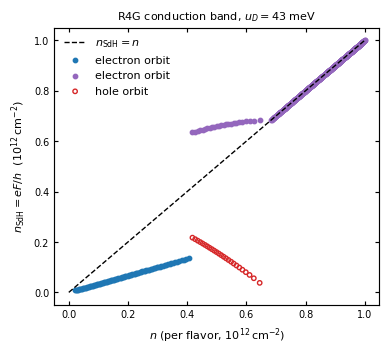

(<Figure size 420x360 with 1 Axes>,
 <Axes: title={'center': 'R4G conduction band, $u_D=43$ meV'}, xlabel='$n$ (per flavor, $10^{12}\\,$cm$^{-2}$)', ylabel='$n_{\\mathrm{SdH}} = eF/h$  ($10^{12}\\,$cm$^{-2}$)'>)

In [206]:
def load_onsager_curves(fname: str) -> dict:
    with h5py.File(fname, "r") as f:
        meta = dict(f.attrs)
        curves = {k: f["curves"][k][:] for k in f["curves"]}
    return meta, curves


def plot(meta: dict, c: dict):
    n = c["n_flavor_e12"]
    nsdh = c["nsdh_e12"]
    el = c["kind"] == 0                                   # 0=electron, 1=hole
    poc3 = c["multiplicity"] == 3                                   # 0=electron, 1=hole

    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    nn = np.linspace(0, n.max() if n.size else 1, 50)
    ax.plot(nn, nn, "k--", lw=1, label=r"$n_{\mathrm{SdH}}=n$")
    ax.scatter(n[el & poc3], nsdh[el & poc3], s=10, c="C0", label="electron orbit")
    ax.scatter(n[el & ~poc3], nsdh[el & ~poc3], s=10, c="C4", label="electron orbit")
    ax.scatter(n[~el], nsdh[~el], s=10, facecolors="none", edgecolors="C3",
               label="hole orbit")
    ax.set_xlabel(r"$n$ (per flavor, $10^{12}\,$cm$^{-2}$)")
    ax.set_ylabel(r"$n_{\mathrm{SdH}} = eF/h$  ($10^{12}\,$cm$^{-2}$)")
    uD = float(meta.get("uD_meV", float("nan")))
    ax.set_title(rf"R4G conduction band, $u_D={uD:g}$ meV")
    ax.legend(fontsize=8, frameon=False)

    plt.show()
    return fig, ax



meta, curves = load_onsager_curves("../data/fig3/r4g_onsager_uD43.h5")
plot(meta, curves)


/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/3400477859.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax.pcolormesh(analyzer.density, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, \


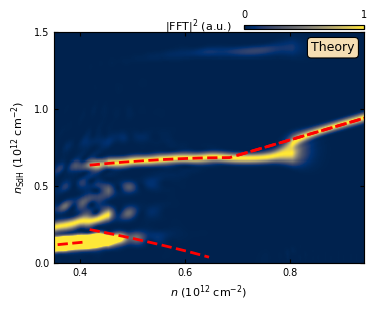

In [209]:
fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.Normalize(vmin=0, vmax=1)
uD, val = 43, 1
file = "../data/fig3/data_LL_uD_{:d}.0_Nll_150_val_{:d}_Bmin_0.01T_Bmax_3.79T_T_0.02500.h5".format(uD, val)
plot = plot_theory_fft(fig, ax, file, norm, "cividis")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
cb.ax.annotate(r'$|\mathrm{FFT}|^2$ (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')   

ax.text(0.97, 0.96, 'Theory', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

plt.show()

# Full figure

[0.00986404 0.01109704 0.01233005 ... 3.78532516 3.78655816 3.78779117]


/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/3649022966.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax.pcolormesh(xs_repeated, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, rasterized=True, lw=0)
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/1597708040.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax.pcolormesh(analyzer.density, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, \


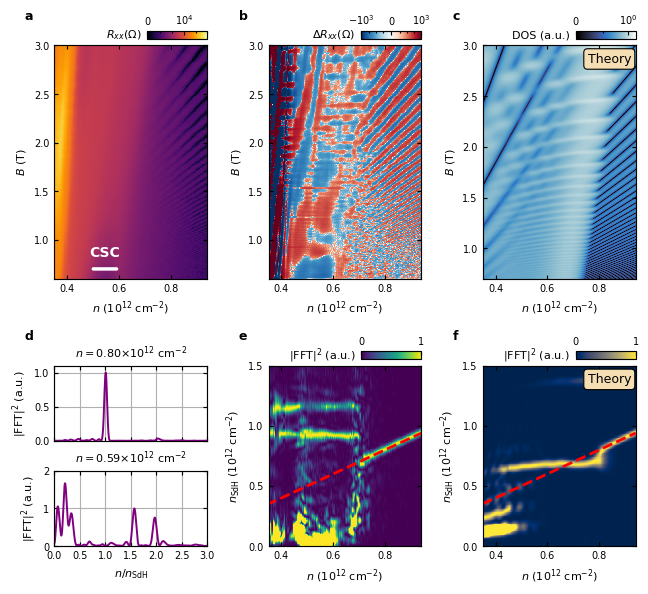

error: Error -2 while flushing: inconsistent stream state

In [75]:
# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 6.5))
gs = GridSpec(3, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1.5, 0.3, 0.3],
                       hspace=0.8, wspace=0.4)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')
norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=1E6)
plot = plot_landau_fan(fig, ax, norm, "inferno")
ax.set_ylim(0.6,3)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 10000], orientation='horizontal')
cb.ax.annotate(r'$R_{xx} (\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticklabels(['$0$', '$10^4$'])

n_left  = 0.5
n_right = 0.59
B_mark1  = 0.8
B_mark2  = 0.65

ax.annotate(
        '',
        xy=(n_left, 0.7), xycoords='data',
        xytext=(n_right, 0.7), textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='white',
            lw=2.5,
            shrinkA=0, shrinkB=0,
            mutation_scale=12,
        ),
    )


ax.text(
    0.5 * (n_left + n_right), 0.8,
    'CSC',
    color='white',
    ha='center', va='bottom',
    fontsize=10, fontweight='bold',
)

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot = plot_landau_fan_detrend(fig, ax, norm, "RdBu_r")
ax.set_ylim(0.6,3)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], orientation='horizontal')
cb.ax.annotate(r'$\Delta R_{xx} (\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticklabels(['$-10^3$', '$0$', '$10^3$'])

################ Panel c ##################
ax = fig.add_subplot(gs[0, 2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "c", fontweight='bold')

norm = colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=2)
uD, val = 43, 1
file = "../data/fig3/data_LL_uD_{:d}.0_Nll_150_val_{:d}_Bmin_0.01T_Bmax_3.79T_T_0.02500.h5".format(uD, val)
plot = plot_theory_LL(fig, ax, file, norm, cmr.arctic)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
cb.ax.annotate('DOS (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')   

ax.text(0.97, 0.97, 'Theory', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

################ Panel d ##################
gs_d = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1:3, 0], hspace=0.4)
ax1 = fig.add_subplot(gs_d[0])
ax2 = fig.add_subplot(gs_d[1])
axarr = [ax1, ax2]

fig.canvas.draw()  
pos = ax1.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "d", fontweight='bold')

analyzer = Lf_analysis(1840, contact=2)
target_densities = [0.8, 0.59]
label_vec = ["QM", "TTM"]
padding = 8
filter_lims = (1, 4)
for density_ind, target_density in enumerate(target_densities):
    ax = axarr[density_ind]
    plot_fft_linecut(fig, ax, target_density=target_density, filter_method="butter", \
                     analyzer=analyzer, norm_skip_fraction=0.04, padding=padding, filter_lims=filter_lims,\
                    linecut_color="purple")
    ax.set_xlim(0, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(7))
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    if density_ind != len(target_densities)-1:
        ax.xaxis.set_ticklabels([])
        ax.set_xlabel("")

    label = label_vec[density_ind]
    ax.set_title("$n = $" + "{:.2f}".format(target_density) + r"$\times 10^{12}$ cm$^{-2}$")
    ax.grid(True)
    
axarr[0].set_ylim(0, 1.1)
axarr[0].yaxis.set_ticks([0, 0.5, 1])
axarr[1].set_ylim(0, 2)
axarr[1].yaxis.set_ticks([0, 1, 2])

################ Panel e ##################
ax = fig.add_subplot(gs[1:3, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "e", fontweight='bold')

norm = colors.Normalize(vmin=0, vmax=1)
plot = plot_fft(fig, ax, norm, "viridis")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
cb.ax.annotate(r'$|\mathrm{FFT}|^2$ (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

################ Panel f ##################
ax = fig.add_subplot(gs[1:3, 2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "f", fontweight='bold')

norm = colors.Normalize(vmin=0, vmax=1)
uD, val = 43, 1
file = "../data/fig3/data_LL_uD_{:d}.0_Nll_150_val_{:d}_Bmin_0.01T_Bmax_3.79T_T_0.02500.h5".format(uD, val)
plot = plot_theory_fft(fig, ax, file, norm, "cividis")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
cb.ax.annotate(r'$|\mathrm{FFT}|^2$ (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')   

ax.text(0.97, 0.96, 'Theory', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

plt.show()
fig.savefig("fig3.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig("fig3.svg", bbox_inches='tight',
            pad_inches=0.02, transparent=True)

# Full fig v2 with effective mass

[0.00986404 0.01109704 0.01233005 ... 3.78532516 3.78655816 3.78779117]


/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/1139927973.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/4038291762.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax.pcolormesh(xs_repeated, unnorm_freqs, norm_psds.T, norm=norm, cmap=cmap, rasterized=True, lw=0)
/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_62410/3400477859.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot =

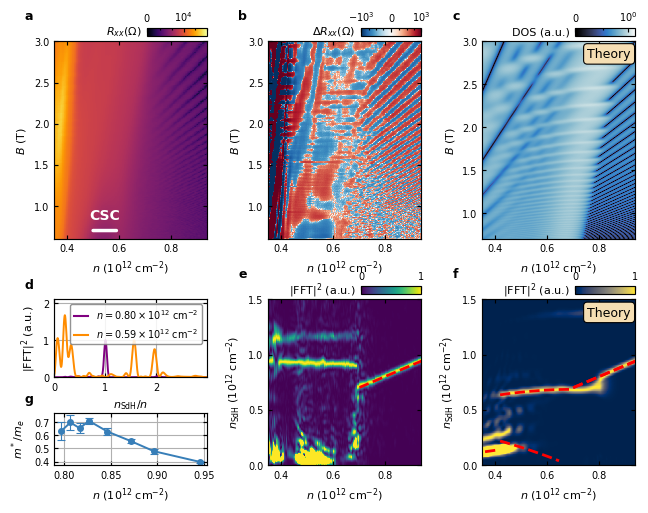

In [210]:
# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 5.5))
gs = GridSpec(3, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1.5, 0.4, 0.4],
                       hspace=0.6, wspace=0.4)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')
norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=1E6)
plot = plot_landau_fan(fig, ax, norm, "inferno")
ax.set_ylim(0.6,3)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 10000], orientation='horizontal')
cb.ax.annotate(r'$R_{xx} (\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticklabels(['$0$', '$10^4$'])

n_left  = 0.5
n_right = 0.59
B_mark1  = 0.8
B_mark2  = 0.65

ax.annotate(
        '',
        xy=(n_left, 0.7), xycoords='data',
        xytext=(n_right, 0.7), textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='white',
            lw=2.5,
            shrinkA=0, shrinkB=0,
            mutation_scale=12,
        ),
    )


ax.text(
    0.5 * (n_left + n_right), 0.8,
    'CSC',
    color='white',
    ha='center', va='bottom',
    fontsize=10, fontweight='bold',
)

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot = plot_landau_fan_detrend(fig, ax, norm, "RdBu_r")
ax.set_ylim(0.6,3)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], orientation='horizontal')
cb.ax.annotate(r'$\Delta R_{xx} (\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top') 
cb.set_ticklabels(['$-10^3$', '$0$', '$10^3$'])

################ Panel c ##################
ax = fig.add_subplot(gs[0, 2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "c", fontweight='bold')

norm = colors.SymLogNorm(linthresh=0.1, vmin=0, vmax=2)
uD, val = 43, 1
file = "../data/fig3/data_LL_uD_{:d}.0_Nll_150_val_{:d}_Bmin_0.01T_Bmax_3.79T_T_0.02500.h5".format(uD, val)
plot = plot_theory_LL(fig, ax, file, norm, cmr.arctic)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
cb.ax.annotate('DOS (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')   

ax.text(0.97, 0.97, 'Theory', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

################ Panel d ##################
gs_d = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1:3, 0], height_ratios=[1.5, 1], hspace=0.55)
ax1 = fig.add_subplot(gs_d[0])
ax2 = fig.add_subplot(gs_d[1])
axarr = [ax1, ax2]

fig.canvas.draw()  
pos = axarr[0].get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + 0.5*label_spacer, "d", fontweight='bold')

pos = axarr[1].get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + 0.5*label_spacer, "g", fontweight='bold')


analyzer = Lf_analysis(1840, contact=2)
target_densities = [0.8, 0.59]
label_vec = ["QM", "MT"]
padding = 4
filter_lims = (1, 4)
linecut_colors = ["#785EF0", "#FFB000"]
linecut_colors = ["purple", "#FF8C00"]
for density_ind, target_density in enumerate(target_densities):
    ax = axarr[0]
    plot_fft_linecut(fig, ax, target_density=target_density, filter_method="butter", \
                     analyzer=analyzer, norm_skip_fraction=0.04, padding=padding, filter_lims = filter_lims,\
                    linecut_color = linecut_colors[density_ind])
    ax.set_xlim(0, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    ax.grid(True)

label_str = "\n".join(
    f"{label}: $n = {d:.2f}\\times 10^{{12}}$ cm$^{{-2}}$"
    for label, d in zip(label_vec, target_densities)
)
legend_handles = [
    mlines.Line2D([], [], color=linecut_colors[i], linewidth=1.5,
                  label=f"$n = {d:.2f}\\times 10^{{12}}$ cm$^{{-2}}$")
    for i, (label, d) in enumerate(zip(label_vec, target_densities))
]
axarr[0].legend(handles=legend_handles, loc='upper right', fontsize=7,
                framealpha=0.85, edgecolor='gray', handlelength=1.5)

axarr[0].set_ylim(0,2.1)
axarr[0].yaxis.set_ticks([0,1,2])
axarr[0].xaxis.set_ticks([0,1,2])
# usage
n_data, mstar_data, err_data = load_mstar("../data/fig3/figS_mstar_qm_B3-B4_big.csv")

num_pts=8
axarr[1].errorbar(n_data[:num_pts], mstar_data[:num_pts], yerr=error_data[:num_pts],
                  marker="o", color="#377EB8", linestyle="-", markersize=4,
                  capsize=3, capthick=0.8, elinewidth=0.8, ecolor="#377EB8")
#axarr[1].plot(n_data[:num_pts], 0.095/(n_data[:num_pts] - 0.7), color="orange")
axarr[1].set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
axarr[1].set_ylabel(r"$m^*/m_e$")
axarr[1].yaxis.set_major_locator(plt.MaxNLocator(4))
axarr[1].grid(True)
plt.tight_layout()

################ Panel e ##################
ax = fig.add_subplot(gs[1:3, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "e", fontweight='bold')

norm = colors.Normalize(vmin=0, vmax=1)
plot = plot_fft(fig, ax, norm, "viridis")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
cb.ax.annotate(r'$|\mathrm{FFT}|^2$ (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

################ Panel f ##################
ax = fig.add_subplot(gs[1:3, 2])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.04
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "f", fontweight='bold')

norm = colors.Normalize(vmin=0, vmax=1)
uD, val = 43, 1
file = "../data/fig3/data_LL_uD_{:d}.0_Nll_150_val_{:d}_Bmin_0.01T_Bmax_3.79T_T_0.02500.h5".format(uD, val)
plot = plot_theory_fft(fig, ax, file, norm, "cividis")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1], orientation='horizontal')
cb.ax.annotate(r'$|\mathrm{FFT}|^2$ (a.u.)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')   

ax.text(0.97, 0.96, 'Theory', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

plt.show()
#fig.savefig("fig3.pdf", dpi=600, bbox_inches='tight',
#            pad_inches=0.02, transparent=False)

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig("fig3.svg", bbox_inches='tight',
            pad_inches=0.02, transparent=True)

# Detrend for various D

In [12]:
file_ids = [1885, 1957, 1840, 1958, 1886, 1888]

/var/folders/q5/6h4h5k9n2t3g39wnfndbzhjr0000gn/T/ipykernel_65084/3712714095.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


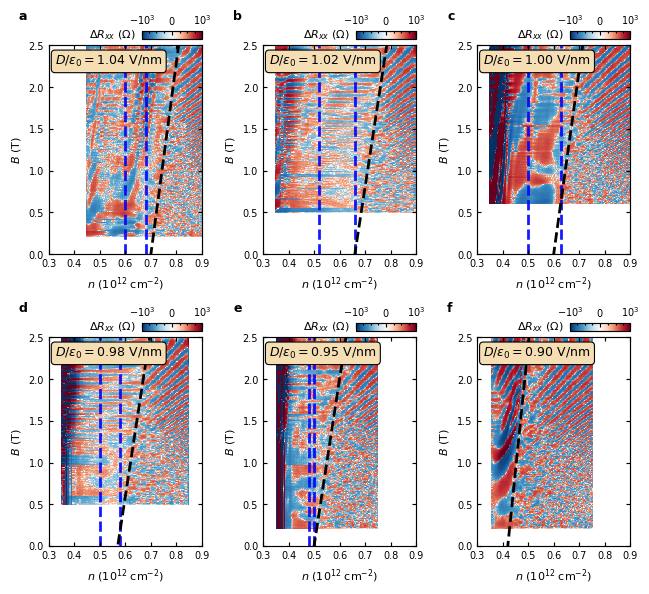

In [22]:
def plot_landau_fan_detrend_file(fig, ax, file, norm, cmap="viridis"):
    analyzer = Lf_analysis(file, contact=2)
    n_vec = analyzer.density
    B_vec, Rxx_detrended = analyzer.get_bg_subtracted_data(bg_method=detrend_butterworth,
                                                           bg_method_params={'cutoff': None, 'order': 4},
                                                           blims=(0.2, 5), return_bg=False)
    plot = ax.pcolormesh(n_vec, B_vec, Rxx_detrended, norm=norm, cmap=cmap, rasterized=True)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlim(0.35, 0.94)
    ax.set_ylim(0, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(7))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot

# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 6.5))
gs = GridSpec(2, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1, 1],
                       hspace=0.4, wspace=0.4)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

ax_locs = [[0,0], [0,1], [0,2], [1,0], [1,1], [1,2]]
panel_labels = ["a", "b", "c", "d", "e", "f"]
Ds = [1.04, 1.02, 1.0, 0.98, 0.95, 0.9]
slope_vec = [23, 20, 22, 20, 20, 30]
n0_vec = [0.70, 0.66, 0.60, 0.57, 0.5, 0.42]

axarr = []
for ind_ax, file in enumerate(file_ids):
    ax = fig.add_subplot(gs[ax_locs[ind_ax][0], ax_locs[ind_ax][1]])
    axarr.append(ax)
    norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
    plot = plot_landau_fan_detrend_file(fig, ax, file, norm, "RdBu_r")

    ax.text(0.04, 0.96, r'$D/\epsilon_0 = {:.2f}$ V/nm'.format(Ds[ind_ax]),
            transform=ax.transAxes, ha='left', va='top', color='k',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                      edgecolor='k', linewidth=0.8, alpha=1))

    fig.canvas.draw()
    pos = ax.get_position()
    label_spacer = 0.04
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, panel_labels[ind_ax],
             fontweight='bold')

    cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
    cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], orientation='horizontal')
    cb.ax.annotate(r'$\Delta R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
                   ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top') 
    cb.set_ticklabels([r'$-10^3$', '$0$', r'$10^3$'])

    ax.set_ylim(0.0, 2.5)
    ax.set_xlim(0.3, 0.9)
    
    analyzer = Lf_analysis(file, contact=2)
    n_vec = analyzer.density
    ax.plot(n_vec, slope_vec[ind_ax]*(n_vec - n0_vec[ind_ax]), color="black", ls="--", lw=2)


sc_ranges = [
(0.60, 0.68),   # brown
(0.52, 0.66),   # purple
(0.50, 0.63),   # red
(0.50, 0.58),   # green
(0.48, 0.50),   # orange
(0.42, 0.42),   # blue — no clear SC pocket
]
for ind, (n_lo, n_hi) in enumerate(sc_ranges):
    # skip last one
    if ind != len(sc_ranges) - 1:
        axarr[ind].axvline(n_lo, color="blue", alpha=0.9, zorder=1, ls="--", lw=2)
        axarr[ind].axvline(n_hi, color="blue", alpha=0.9, zorder=1, ls="--", lw=2)

plt.tight_layout()
plt.show()
fig.savefig("fig-detrend-vs-D.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)